## 2D Random Walk
With constant magnitude of displacement for each time step.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
displacement_mag = 1 #fixed the magnitude of discplacement to be constant
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

In [ ]:
#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        #print(r2)
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

In [ ]:
def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1): 
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

In [ ]:
#particle1 = generate_trajectory(1000, starting_position)
particle2 = generate_trajectory(10, starting_position)
particle3 = generate_trajectory(1000, starting_position)

#print(particle1)
print(particle2)

print(calculate_MSD(2, particle2))
#print(calculate_MSD(10, particle1))
print(calculate_MSD(50, particle3))

In [ ]:
particle1 = generate_trajectory(1000, starting_position)
particle1_data = generate_MSD_dataset(10, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

However, closer to actual Brownian motion, the magnitude of displacement need not be constant all the time… Instead it may be a more realistic simulation to choose a magnitude of displacement from a normal distribution for each time step. 

In [ ]:
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    #displacement= np.random.normal(loc=1, scale=2)
    #angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = np.random.normal(loc=0, scale=1)
    y_direction = np.random.normal(loc=0, scale=1)
    #print(x_direction, y_direction)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

In [ ]:
generate_direction_vector()

In [ ]:
particle1 = generate_trajectory(100, starting_position)
particle1_data = generate_MSD_dataset(10, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

In [ ]:
particle1 = generate_trajectory(1000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

In [ ]:
particle1 = generate_trajectory(100000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

In [ ]:
particle1 = generate_trajectory(1000000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

What happens when we enforce boundaries on how far the particle can actually travel? Will that change the shape of the MSD on time graph? 

In [ ]:
"""
(-5, 5) -------- (5,5)
|
|
|
|
(-5, -5) -------- (-5,5)

"""

def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return np.array([x_direction, y_direction])

def rebound_at_boundary(boundary_x, boundary_y, next_step):
    #rightcorner
    magnitude = abs(next_step)
    boundary_violated = magnitude - np.array([boundary_x, boundary_y]) > np.array([0,0])
    x = next_step[0]
    y = next_step[1]
    if boundary_violated[0]:
        if x > 0:
            x = boundary_x - (x - boundary_x)
        else:
            x = -boundary_x - (x + boundary_x) 
    if boundary_violated[1]:
        if y > 0:
            y = boundary_y - (y - boundary_y)
        else:
            y = -boundary_y - (y + boundary_y)
    return np.array([x,y])
 
def generate_trajectory(time, starting_position, boundary_x, boundary_y):
    trajectory = [np.concatenate((np.array([0]), starting_position))]
    current_position = starting_position.copy()
    current_time = 0
    while current_time < time:
        current_time += 1
        next_step = current_position + generate_direction_vector().copy()
        current_position = rebound_at_boundary(boundary_x, boundary_y, next_step)
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
    return trajectory 

In [ ]:
boundary_x = 1
boundary_y = 1
trajectory1 = generate_trajectory(100, np.array([0,0], dtype=float), boundary_x, boundary_y)
print(trajectory1)

#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]


particle1 = generate_trajectory(1000000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 2
boundary_y = 2

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 5
boundary_y = 5

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 10
boundary_y = 10

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 100
boundary_y = 100

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


Clearly, as the boundary of the container increases, the behaviour of the graph tends to what we would expect without boundary in part 1 (boundary of the graph goes to infinity). 
Otherwise, for a small enough container, the MSD plateaus after a certain threshold in time. Why?

In [188]:
%pip install ipympl

Note: you may need to restart the kernel to use updated packages.


In [3]:
#will attempt to use the langevin model to simulate the motion of the tagged particle. 

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

#initialises a particular arrangement of the background particles for given number of background particles and container size (square)
def initialise_background(number_of_particles, container_length):
    background_initial = []
    for number in range(number_of_particles):
        x_coordinate = np.random.uniform(0, container_length)
        y_coordinate = np.random.uniform(0, container_length)
        background_initial.append(np.array([x_coordinate, y_coordinate]))
    return background_initial

#to generate the random motion of the background particles 
def generate_direction_vector(velocity_background):
    magnitude = velocity_background
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = magnitude*math.cos(angle)
    y_direction = magnitude*math.sin(angle)
    return np.array([x_direction, y_direction])

def rebound_at_boundary(boundary_x, boundary_y, next_step):
    #rightcorner
    magnitude = abs(next_step)
    boundary_violated = magnitude - np.array([boundary_x, boundary_y]) > np.array([0,0])
    x = next_step[0]
    y = next_step[1]
    if boundary_violated[0]:
        if x > 0:
            x = boundary_x - (x - boundary_x)
        else:
            x = -boundary_x - (x + boundary_x) 
    if boundary_violated[1]:
        if y > 0:
            y = boundary_y - (y - boundary_y)
        else:
            y = -boundary_y - (y + boundary_y)
    return np.array([x,y])

def update_background_position(background_history, velocity_background, container_length):
    updated_positions = []
    for particle in background_history[-1]:
        #print(particle)
        hypothetical = particle + generate_direction_vector(velocity_background)
        actual_position = rebound_at_boundary(container_length, container_length, hypothetical)
        updated_positions.append(actual_position)
    #print(actual_position)
    return np.array(updated_positions)
    

In [4]:
initialise = initialise_background(number_of_particles=2, container_length=10)
background_history = [initialise]
#print(initialise)
new_positions = update_background_position(background_history=background_history, velocity_background=10, container_length=10)
background_history.append(new_positions)

print(np.array(background_history)[:,0])

[[2.91988429 7.03689964]
 [7.12333635 6.10816682]]


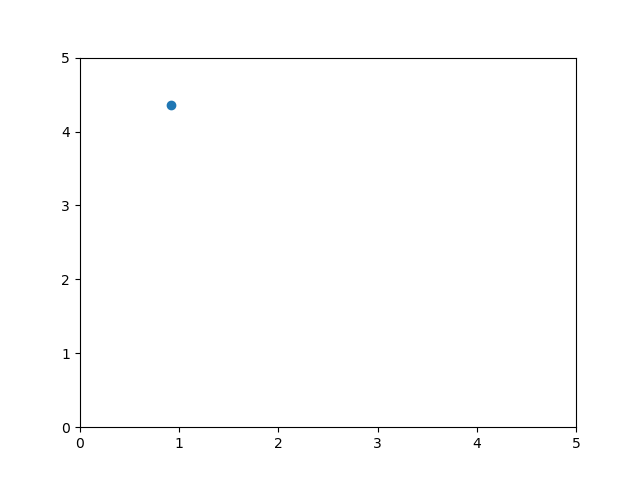

In [7]:
container_length = 5 #set size of container 
number_of_particles = 1 #number of background particles 
viscosity_of_fluid = 1 #the visosity of fluid needed to compute drag on tagged particle
velocity_tagged = 0 #the velocity of the tagged particle 
velocity_background = 1 #the average velocity of the bakground particle, proportional to temeprature. 
# For sake of simulation, we will assume the bacground particles to be travelling at constant velocity. 

time_difference = 1 #modify later, default to 1s between frames for now. 

background_particle_history = [] #position of background particles per timestep
tagged_particle_history = [] #position of tagged particle per timestep

tagged_particle_pos = np.array([container_length/2,container_length/2], dtype=float) #initialise position of tagged particle to be at the centre of the container 
tagged_particle_history.append(tagged_particle_pos) #first history point should be the initial position at t0. 

background_positions = initialise_background(number_of_particles=number_of_particles, container_length=container_length)
background_particle_history.append(background_positions.copy())

fig,ax =plt.subplots()
ax.set_xlim(0, container_length)
ax.set_ylim(0, container_length)
#ax.set_aspect("equal")

background_scatter = ax.scatter(
    np.array(background_positions)[:,0],
    np.array(background_positions)[:,1],
    label="background particles"
)

#tagged_scatter

#ax.legend()

def animate_particles(frame):
    background_positions = update_background_position(
        background_history=background_particle_history,
        velocity_background=velocity_background,
        container_length=container_length)
    background_particle_history.append(background_positions.copy())
    background_scatter.set_offsets(background_positions)

    return background_scatter

animation = FuncAnimation(
    fig,
    animate_particles,
    frames=1,
    interval=500,
    blit=False
)

plt.show()
